    Gamma ray (KeV)  Counts  Counts uncertainty    BG  BG uncertainty  BG subtracted counts  BG subtracted uncertainty   Sample  Sample uncertainty  Emission rate  Emission rate uncertainty  Efficiency  Efficiency uncertainty
0                46   481.0                33.0   497              67               418.875                  34.046154      NaN                 NaN           1.48                       0.07    1.132095                0.106462
1                63  1458.0                64.0  2913             155              1093.875                  66.868458      NaN                 NaN           1.29                       0.06    3.391860                0.260538
2                93  2466.0                66.0  3171             113              2069.625                  67.494560      NaN                 NaN           0.73                       0.04   11.340411                0.723122
3               186  1759.0                40.0  1799              90              1534.125     

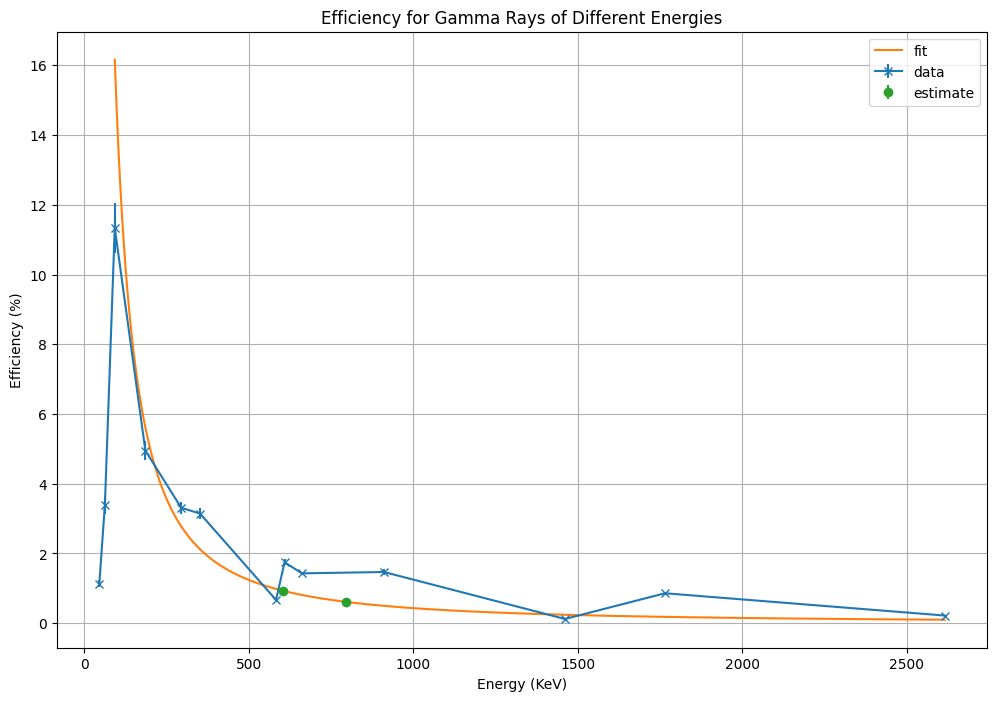

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.odr import ODR, Model, RealData

# Import data from table in question
data = {
    "Gamma ray (KeV)": np.array([
        46, 63, 93, 186,
        295, 352, 583, 605,
        609, 662, 795, 911,
        1461, 1765, 2615
    ]),
    "Counts": np.array([
        481, 1458, 2466, 1759,
        5353, 9816, 3328, np.nan,
        7023, 6063, np.nan, 2209,
        1314, 1145, 1283
    ]),
    "Counts uncertainty": np.array([
        33, 64, 66, 40,
        59, 76, 44, np.nan,
        69, 66, np.nan, 36,
        30, 26, 26
    ]),
    "BG": np.array([
        497, 2913, 3171, 1799,
        266, 334, 328, 1028,
        1028, 193, 218, 82,
        1207, 26, 138
    ]),
    "BG uncertainty": np.array([
        67, 155, 113, 90,
        77, 72, 63, 129,
        129, 76, 119, 41,
        63, 38, 45
    ]),
    "Sample": np.array([
        np.nan, np.nan, np.nan, np.nan,
        np.nan, np.nan, np.nan, 41684,
        np.nan, 76312, 32363, np.nan,
        np.nan, np.nan, np.nan
    ]),
    "Sample uncertainty": np.array([
        np.nan, np.nan, np.nan, np.nan,
        np.nan, np.nan, np.nan, 219,
        np.nan, 279, 184, np.nan,
        np.nan, np.nan, np.nan
    ]),
    "Emission rate": np.array([
        1.48, 1.29, 0.73, 1.24,
        6.43, 12.43, 19.7, np.nan,
        15.8, 16.9, np.nan, 5.99,
        38.5, 5.32, 23.1
    ]),
    "Emission rate uncertainty": np.array([
        0.07, 0.06, 0.04, 0.06,
        0.32, 0.63, 0.94, np.nan,
        0.8, 0.3, np.nan, 0.28,
        2, 0.23, 1.1
    ])
}

# Convert to pandas df, set constants
df = pd.DataFrame(data)
count_time = 25e3
bg_time = 200e3
sample_time = 5e3

# Compute background subtraction and efficiencies
# Uncertainties propagated as well
bg_sub_counts = df["Counts"] - (count_time/bg_time)*df["BG"]
err_bg_sub = np.sqrt(df["Counts uncertainty"] ** 2 + ((count_time / bg_time) * df["BG uncertainty"]) ** 2)
eff = (bg_sub_counts / (df["Emission rate"] * count_time)) * 100
err_eff = (eff * np.sqrt(
    (err_bg_sub / bg_sub_counts) ** 2 + (df["Emission rate uncertainty"] / df["Emission rate"]) ** 2
))

# Add bg subtracted counts, efficiencies, etc. to df
df.insert(5, "BG subtracted counts", bg_sub_counts)
df.insert(6, "BG subtracted uncertainty", err_bg_sub)
df.insert(11, "Efficiency", eff)
df.insert(12, "Efficiency uncertainty", err_eff)

print(df.to_string())

x_partb = df["Gamma ray (KeV)"][~np.isnan(df["Efficiency"])]
y_partb = df["Efficiency"][~np.isnan(df["Efficiency"])]
err_partb = df["Efficiency uncertainty"][~np.isnan(df["Efficiency"])]

def eff_exp(B, x):
    a, b = B
    return a*x.astype(float)**b

fit = ODR(RealData(x_partb[2:], y_partb[2:], sy=err_partb[2:]), Model(eff_exp), beta0=[10, -1]).run()

plt.figure(figsize=(12, 8))
plt.title("Efficiency for Gamma Rays of Different Energies")
plt.xlabel("Energy (KeV)")
plt.ylabel("Efficiency (%)")
plt.errorbar(
    x_partb,
    y_partb,
    yerr=err_partb,
    label="data",
    fmt="-x"
)
fit_x = np.arange(93, 2615, 0.1)
plt.plot(
    fit_x,
    eff_exp(fit.beta, fit_x),
    label="fit"
)

# Estimate the efficiency for both Cs134 rays
cs134_rays = np.array([605., 795.])
eff_pred = eff_exp(fit.beta, cs134_rays)

# Extract fit parameters and covariance matrix
a, b = fit.beta
cov = fit.cov_beta
var_a = cov[0,0]
var_b = cov[1,1]
cov_ab = cov[0,1]

# Derivatives
d_da = cs134_rays**b
d_db = eff_pred * np.log(cs134_rays)

# Variance propagation, convert to uncertainty
err_eff_pred = np.sqrt(d_da ** 2 * var_a + d_db ** 2 * var_b + 2 * d_da * d_db * cov_ab)

plt.errorbar(
    cs134_rays,
    eff_pred,
    yerr=err_eff_pred,
    fmt="o",
    label="estimate"
)

plt.grid()
plt.legend()
plt.show()